# Analyze Trajectories 

- detect movements of parties triggered by crisis
- analyze trajectories of MPs that changed parties

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from aggregation_functions import aggregate_by_mp_year, aggregate_by_party_year

In [ ]:
# data frame with speech to topic assignments
df_topics = pd.read_csv('speech_topic_assignments.csv')
df_topics

,speaker_id,party,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name,date
0,11001434,SPD,604683,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft",2000-01-19
1,11002754,CDU/CSU,604883,11,"Bildung, Familie und Jugend",11,"Bildung, Familie und Jugend",2000-01-20
2,11000431,SPD,604885,11,"Bildung, Familie und Jugend",11,"Bildung, Familie und Jugend",2000-01-20
3,11001180,FDP,604905,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr,2000-01-20
4,11003216,CDU/CSU,605067,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr,2000-01-21
...,...,...,...,...,...,...,...,...
82442,11004381,SPD,1060945,19,Kultur und Medien,19,Kultur und Medien,2021-05-07
82443,11004854,CDU/CSU,1060947,18,Europapolitik und EU-Angelegenheiten,18,Europapolitik und EU-Angelegenheiten,2021-05-07
82444,11004802,SPD,1060949,18,Europapolitik und EU-Angelegenheiten,18,Europapolitik und EU-Angelegenheiten,2021-05-07
82445,11004802,SPD,1060955,15,Menschenrechte und humanitäre Hilfe,15,Menschenrechte und humanitäre Hilfe,2021-05-07


In [4]:
# data frame with fine tuned embeddings
df_embeddings = pd.read_parquet("jina_v3_contrastive_full.parquet")
df_embeddings

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,year,year_month,n_tokens,used_in_finetune,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding
0,604683,Meine werten Kolleginnen und Kollegen! Liebe K...,11001434,Christoph Matschie,Christoph,Matschie,Member of Parliament,23,SPD,2000-01-19,2000,2000-01,1209,False,False,False,True,"[0.03820973, -0.11824905, 0.035603546, -0.0051..."
1,604883,Rot-grün und Bildungsministerin Bulmahn sind w...,11002754,thomas rachel,thomas,rachel,Member of Parliament,4,CDU/CSU,2000-01-20,2000,2000-01,988,False,False,False,True,"[0.043069527, -0.1234621, 0.08022803, 0.004297..."
2,604885,Meine sehr verehrten Damen und Herren! Ich ste...,11000431,peter eckardt,peter,eckardt,Member of Parliament,23,SPD,2000-01-20,2000,2000-01,1087,False,False,False,True,"[0.03223048, -0.10839531, 0.07345019, -0.00229..."
3,604905,Die aktuelle Lage der deutschen Werftindustrie...,11001180,jürgen koppelin,jürgen,koppelin,Member of Parliament,13,FDP,2000-01-20,2000,2000-01,1550,False,False,False,True,"[0.057155393, -0.12872227, 0.027934263, -0.038..."
4,605067,Verehrte Frau Wehrbeauftragte! Liebe Kolleginn...,11003216,anita schäfer,anita,schäfer,Member of Parliament,4,CDU/CSU,2000-01-21,2000,2000-01,1552,False,False,False,True,"[0.022645857, -0.14240317, 0.05878738, -0.0094..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82442,1060945,"Es ist schon ein besonderer Treppenwitz, dass ...",11004381,Martin Rabanus,Martin,Rabanus,Member of Parliament,23,SPD,2021-05-07,2021,2021-05,991,False,False,False,True,"[0.106144175, -0.11403943, 0.059873722, 0.0198..."
82443,1060947,Verehrte Kolleginnen und Kollegen! Ich teile n...,11004854,Christoph Ploß,Christoph,Ploß,Member of Parliament,4,CDU/CSU,2021-05-07,2021,2021-05,943,False,False,False,True,"[0.068563156, -0.08838378, 0.11244867, -0.0153..."
82444,1060949,"Jetzt fühle mich fast an „Blockwart“ erinnert,...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,2021,2021-05,1153,False,False,False,True,"[0.10353798, -0.07043955, 0.06072252, 0.011076..."
82445,1060955,"Gut, ich beschränke mich auf einen Satz: Ich p...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,2021,2021-05,197,False,False,False,True,"[0.098100424, -0.12857388, 0.083329365, 0.0245..."


In [5]:
# merge embedding and topics data frame
df_embeddings_topics = df_embeddings.merge(
    df_topics.drop(columns=["party", "date"]),
    left_on="id", right_on="speech_id",
    how="inner"
)

df_embeddings_topics = df_embeddings_topics[df_embeddings_topics.party != 'Fraktionslos']
df_embeddings_topics

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
0,604683,Meine werten Kolleginnen und Kollegen! Liebe K...,11001434,Christoph Matschie,Christoph,Matschie,Member of Parliament,23,SPD,2000-01-19,...,False,False,True,"[0.03820973, -0.11824905, 0.035603546, -0.0051...",11001434,604683,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft"
1,604883,Rot-grün und Bildungsministerin Bulmahn sind w...,11002754,thomas rachel,thomas,rachel,Member of Parliament,4,CDU/CSU,2000-01-20,...,False,False,True,"[0.043069527, -0.1234621, 0.08022803, 0.004297...",11002754,604883,11,"Bildung, Familie und Jugend",11,"Bildung, Familie und Jugend"
2,604885,Meine sehr verehrten Damen und Herren! Ich ste...,11000431,peter eckardt,peter,eckardt,Member of Parliament,23,SPD,2000-01-20,...,False,False,True,"[0.03223048, -0.10839531, 0.07345019, -0.00229...",11000431,604885,11,"Bildung, Familie und Jugend",11,"Bildung, Familie und Jugend"
3,604905,Die aktuelle Lage der deutschen Werftindustrie...,11001180,jürgen koppelin,jürgen,koppelin,Member of Parliament,13,FDP,2000-01-20,...,False,False,True,"[0.057155393, -0.12872227, 0.027934263, -0.038...",11001180,604905,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr
4,605067,Verehrte Frau Wehrbeauftragte! Liebe Kolleginn...,11003216,anita schäfer,anita,schäfer,Member of Parliament,4,CDU/CSU,2000-01-21,...,False,False,True,"[0.022645857, -0.14240317, 0.05878738, -0.0094...",11003216,605067,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82442,1060945,"Es ist schon ein besonderer Treppenwitz, dass ...",11004381,Martin Rabanus,Martin,Rabanus,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.106144175, -0.11403943, 0.059873722, 0.0198...",11004381,1060945,19,Kultur und Medien,19,Kultur und Medien
82443,1060947,Verehrte Kolleginnen und Kollegen! Ich teile n...,11004854,Christoph Ploß,Christoph,Ploß,Member of Parliament,4,CDU/CSU,2021-05-07,...,False,False,True,"[0.068563156, -0.08838378, 0.11244867, -0.0153...",11004854,1060947,18,Europapolitik und EU-Angelegenheiten,18,Europapolitik und EU-Angelegenheiten
82444,1060949,"Jetzt fühle mich fast an „Blockwart“ erinnert,...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.10353798, -0.07043955, 0.06072252, 0.011076...",11004802,1060949,18,Europapolitik und EU-Angelegenheiten,18,Europapolitik und EU-Angelegenheiten
82445,1060955,"Gut, ich beschränke mich auf einen Satz: Ich p...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.098100424, -0.12857388, 0.083329365, 0.0245...",11004802,1060955,15,Menschenrechte und humanitäre Hilfe,15,Menschenrechte und humanitäre Hilfe


## 1. Detect Crisis

We test if the following political events appear as detectable movements in the embedding space (embeddings aggregated by MP and year): 

- 9/11 terror attacks
- Lehman Brothers collapse / global financial crisis
- Fukushima nuclear disaster
- Shift to migration scepticism in Germany (post-Cologne NYE)

To test, whether those events trigger movements of the embeddings, we first have to filter for related topics.


In [6]:
# List of all topics 
print(df_embeddings_topics.topic_emb_full_name.unique())

['Umweltschutz, Klimapolitik und Atomkraft' 'Bildung, Familie und Jugend'
 'Verteidigungspolitik und Bundeswehr' 'Verkehr und Infrastruktur'
 'Gesundheitspolitik und Krankenversicherung'
 'Landwirtschaft und Ernährung' 'Steuern und Finanzpolitik'
 'Europapolitik und EU-Angelegenheiten' 'Wohnungspolitik und Städtebau'
 'Wirtschaftspolitik und Energieversorgung'
 'Menschenrechte und humanitäre Hilfe'
 'Außenpolitik und internationale Beziehungen'
 'Arbeitsmarkt und Sozialpolitik' 'Innere Sicherheit und Polizei'
 'Recht und Verbraucherschutz' 'Kultur und Medien'
 'Migration, Asyl und Einwanderung' 'Forschung, Technologie und Raumfahrt'
 'Sport und Ehrenamt' 'Bundeshaushalt und öffentliche Ausgaben'
 'Entwicklungszusammenarbeit']


### 9/11 terror attacks
Topic related to 9/11 terror attacks: 
- 'isaf-mandats/isaf-mission/karzai' ("ISAF mandate / ISAF mission / Karzai")

In [ ]:
df_9_11 = df_embeddings_topics[df_embeddings_topics.topic_emb_raw_name =='isaf-mandats/isaf-mission/karzai']

df_9_11

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
5222,625985,Die Freien Demokraten lehnen den Antrag der Bu...,11002944,Guido Westerwelle,Guido,Westerwelle,Member of Parliament,13,FDP,2001-06-01,...,False,False,True,"[0.0484316, -0.12063529, 0.05465001, -0.021245...",11002944,625985,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
5227,625999,Im Gegensatz zu Herrn Kollegen Merz möchte ich...,11000489,Gernot Erler,Gernot,Erler,Member of Parliament,23,SPD,2001-06-01,...,False,False,True,"[0.088499345, -0.117718354, 0.040650938, -0.02...",11000489,625999,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
5923,628942,"Nein, im Augenblick nicht. Ich bitte um Entsch...",11002278,Peter Struck,Peter,Struck,Member of Parliament,23,SPD,2001-10-11,...,False,False,True,"[0.03628148, -0.16026206, 0.06403307, -0.05424...",11002278,628942,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
6077,629572,"Vielen Dank, Herr Präsident! Es ist nicht das ...",11000996,Ulrich Irmer,Ulrich,Irmer,Member of Parliament,13,FDP,2001-10-18,...,False,False,True,"[0.03268463, -0.14294992, 0.088626824, -0.0324...",11000996,629572,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
6080,629582,Verehrte Kolleginnen und Kollegen! Wer in eine...,11000181,Rudolf Bindig,Rudolf,Bindig,Member of Parliament,23,SPD,2001-10-18,...,False,False,True,"[0.05239607, -0.16260496, 0.09905398, -0.02258...",11000181,629582,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82424,1060876,Vor allem: Lieber Herr Kollege Lucassen! Sie s...,11004656,Philipp Amthor,Philipp,Amthor,Member of Parliament,4,CDU/CSU,2021-05-07,...,False,False,True,"[0.074197166, -0.12993331, 0.08358965, -0.0191...",11004656,1060876,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
82425,1060880,"Ich bin ganz irritiert, Herr Amthor, dass wir ...",11004906,Marie-Agnes Strack-Zimmermann,Marie-Agnes,Strack-Zimmermann,Member of Parliament,13,FDP,2021-05-07,...,False,False,True,"[0.039036125, -0.13014202, 0.089285806, -0.015...",11004906,1060880,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
82426,1060884,Die Bundeswehr befindet sich derzeit in zehn m...,11004361,Alexander S. Neu,Alexander S.,Neu,Member of Parliament,6,LINKE,2021-05-07,...,False,False,True,"[0.06730394, -0.1388349, 0.06838469, -0.022937...",11004361,1060884,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
82428,1060890,Sehr verehrte Frau Präsidentin! Meine verehrte...,11004256,Karl-Heinz Brunner,Karl-Heinz,Brunner,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.075418845, -0.1311105, 0.0935403, 0.0201109...",11004256,1060890,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai


### Lehman Brothers collapse / global financial crisis
Topic related to Lehman Brothers collapse / global financial crisis: 
- 'pfandbrief/vermögensanlagen/kapitalanlagegesetzbuch' ("covered bond (Pfandbrief) / asset investments / capital investment code")

In [7]:
df_financial_crisis = df_embeddings_topics[df_embeddings_topics.topic_emb_full_name == 'pfandbrief/vermögensanlagen/kapitalanlagegesetzbuch']
df_financial_crisis

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
545,606528,Das neue Insolvenzrecht ist bekanntlich vor gu...,11003159,evelyn kenzler,evelyn,kenzler,Member of Parliament,22,PDS,2000-02-18,...,False,False,True,"[0.07557646, -0.05016817, 0.01691161, 0.001943...",11003159,606528,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
704,607153,"Ich hatte gestern Abend das Vergnügen, mit dem...",11002093,dietmar schütz,dietmar,schütz,Member of Parliament,23,SPD,2000-02-25,...,False,False,True,"[0.09834212, -0.12836099, 0.043255042, -0.0057...",11002093,607153,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
863,608200,Meine sehr verehrten Damen und Herren! Die ang...,11001319,Klaus Lennartz,Klaus,Lennartz,Member of Parliament,23,SPD,2000-03-23,...,False,False,True,"[0.09510677, -0.0747031, 0.016247753, -0.03928...",11001319,608200,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
908,608220,Verehrte Kolleginnen und Kollegen! Der Vorgang...,11002728,Christa Luft,Christa,Luft,Member of Parliament,22,PDS,2000-03-23,...,False,False,True,"[0.10418292, -0.075572535, -0.010280163, -0.02...",11002728,608220,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
919,608202,"das mache ich -, die nicht nur vom Schreibtisc...",11001319,Klaus Lennartz,Klaus,Lennartz,Member of Parliament,23,SPD,2000-03-23,...,False,False,True,"[0.11537251, -0.082092434, -0.021792363, -0.03...",11001319,608202,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81646,1058424,Man muss sagen: Das ist ja eine einigermaßen h...,11003050,Lothar Binding,Lothar,Binding,Member of Parliament,23,SPD,2021-04-15,...,False,False,True,"[0.087703556, -0.11116112, 0.000881334, -0.005...",11003050,1058424,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
82011,1059527,Der im Gesetz gewählte Ansatz einer Standort- ...,11004693,Jörg Cezanne,Jörg,Cezanne,Member of Parliament,6,LINKE,2021-04-22,...,False,False,True,"[0.12070217, -0.0970909, -0.028573353, -0.0243...",11004693,1059527,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
82344,1060614,Vielen Dank. – Herr Präsident! Liebe Kolleginn...,11003050,Lothar Binding,Lothar,Binding,Member of Parliament,23,SPD,2021-05-06,...,False,False,True,"[0.11310496, -0.099049255, 0.01959681, 0.00182...",11003050,1060614,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
82345,1060618,Mit dem Schwarmfinanzierungs-Begleitgesetz bri...,11004684,Carsten Brodesser,Carsten,Brodesser,Member of Parliament,4,CDU/CSU,2021-05-06,...,False,False,True,"[0.043757625, -0.052062307, -0.008626161, 0.01...",11004684,1060618,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...


### Fukushima nuclear disaster
Topics related to 'Fukushima nuclear disaster': 
- 'schwarzelühr-sutter/reaktorsicherheit/reaktoren' ("Schwarzelühr-Sutter (a surname) / reactor safety / reactors").
- 'entsorgungskonzept/salzstocks/sellafield' ("disposal concept / salt domes / Sellafield")

In [8]:
df_fukushima = df_embeddings_topics[df_embeddings_topics.topic_emb_full_name.isin(['schwarzelühr-sutter/reaktorsicherheit/reaktoren', 'entsorgungskonzept/salzstocks/sellafield'])]
df_fukushima

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
43,616578,"Man kann es drehen, wie man will: In den Augen...",11002678,Walter Hirche,Walter,Hirche,Member of Parliament,13,FDP,2000-11-15,...,False,False,True,"[0.08811338, -0.12637773, 0.05681287, 3.15967e...",11002678,616578,29,entsorgungskonzept/salzstocks/sellafield,29,entsorgungskonzept/salzstocks/sellafield
45,616776,"Wir haben von der früheren DDR-Regierung, von ...",11001353,Klaus W Lippold,Klaus W,Lippold,Member of Parliament,4,CDU/CSU,2000-11-16,...,False,False,True,"[0.075086564, -0.12212144, 0.023355529, -0.031...",11001353,616776,29,entsorgungskonzept/salzstocks/sellafield,29,entsorgungskonzept/salzstocks/sellafield
171,604915,Der schwerste Reaktorunfall in der westlichen ...,11001293,paul laufs,paul,laufs,Member of Parliament,4,CDU/CSU,2000-01-20,...,False,False,True,"[0.13581339, -0.116223566, 0.047298197, 0.0051...",11001293,604915,29,entsorgungskonzept/salzstocks/sellafield,29,entsorgungskonzept/salzstocks/sellafield
172,604917,Wir behandeln heute in erster Lesung einen kur...,11001234,horst kubatschka,horst,kubatschka,Member of Parliament,23,SPD,2000-01-20,...,False,False,True,"[0.093415335, -0.059045605, 0.0424054, 0.00773...",11001234,604917,29,entsorgungskonzept/salzstocks/sellafield,29,entsorgungskonzept/salzstocks/sellafield
173,604919,Meine Kolleginnen und Kollegen! Ich möchte zun...,11000952,birgit homburger,birgit,homburger,Member of Parliament,13,FDP,2000-01-20,...,False,False,True,"[0.09269338, -0.10441279, 0.03717757, -0.02063...",11000952,604919,-1,unassigned,29,entsorgungskonzept/salzstocks/sellafield
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81530,1058084,Meine sehr verehrten Damen und Herren! Als ich...,11004732,Timon Gremmels,Timon,Gremmels,Member of Parliament,23,SPD,2021-04-13,...,False,False,True,"[0.073475845, -0.068871774, 0.02380795, -0.022...",11004732,1058084,29,entsorgungskonzept/salzstocks/sellafield,29,entsorgungskonzept/salzstocks/sellafield
81531,1058086,Es geht heute um die Energieversorgung in Deut...,11004120,Martin Neumann,Martin,Neumann,Member of Parliament,13,FDP,2021-04-13,...,False,False,True,"[0.098377086, -0.09993328, 0.05341199, -0.0281...",11004120,1058086,-1,unassigned,29,entsorgungskonzept/salzstocks/sellafield
81534,1058092,Ich will noch mal deutlich machen: Natürlich b...,11004120,Martin Neumann,Martin,Neumann,Member of Parliament,13,FDP,2021-04-13,...,False,False,True,"[0.10527904, -0.14324795, 0.044987656, -0.0053...",11004120,1058092,-1,unassigned,29,entsorgungskonzept/salzstocks/sellafield
81535,1058102,Im April 1986 war ich sieben Jahre alt. Ich wa...,11004672,Lorenz Gösta Beutin,Lorenz Gösta,Beutin,Member of Parliament,6,LINKE,2021-04-13,...,False,False,True,"[0.10541044, -0.15859087, 0.027539007, -0.0110...",11004672,1058102,29,entsorgungskonzept/salzstocks/sellafield,29,entsorgungskonzept/salzstocks/sellafield


### Shift to migration scepticism in Germany (post-Cologne NYE)

Topic related to Shift to migration scepticism in Germany (post-Cologne NYE):   
- 'mehrstaatigkeit/dublin-ii-verordnung/optionspflicht' ("multiple nationality / Dublin II regulation / option requirement")


In [9]:
df_migration = df_embeddings_topics[df_embeddings_topics.topic_emb_raw_name.isin(['mehrstaatigkeit/dublin-ii-verordnung/optionspflicht',
    "zwangsverheiratungen/einbürgerungen/ehegattennachzug",
    "militärmission/flüchtlingsabwehr/militärausgaben"])]

df_migration

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
147,604841,Der Kollege Tauss ist ja am Schluss derart in ...,11002678,walter hirche,walter,hirche,Member of Parliament,13,FDP,2000-01-20,...,False,False,True,"[0.070309855, -0.12695086, 0.07869413, 0.03328...",11002678,604841,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
390,606019,"Herr Minister, zunächst eine ganz kurze Vorbem...",11002770,Hartmut Schauerte,Hartmut,Schauerte,Member of Parliament,4,CDU/CSU,2000-02-16,...,False,False,True,"[0.041170742, -0.16246921, 0.07832348, 0.01728...",11002770,606019,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
779,607535,Aufgrund einer Initiative der CDU/CSU-Bundesta...,11002632,Wolfgang Bosbach,Wolfgang,Bosbach,Member of Parliament,4,CDU/CSU,2000-03-16,...,False,False,True,"[0.04356148, -0.12328048, 0.074834384, 0.02726...",11002632,607535,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
780,607537,Auch wenn dieses Angebot noch so freundlich ge...,11003249,Rüdiger Veit,Rüdiger,Veit,Member of Parliament,23,SPD,2000-03-16,...,False,False,True,"[0.04441368, -0.111941434, 0.08770614, 0.02239...",11003249,607537,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
781,607550,"Innenminister Schily hat gesagt, das Problem l...",11003247,Hans-Peter Uhl,Hans-Peter,Uhl,Member of Parliament,4,CDU/CSU,2000-03-16,...,False,False,True,"[0.01720537, -0.1693599, 0.13183902, 0.0236222...",11003247,607550,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81314,1057395,"Nein, danke. – Vor allem stellt sich mir die F...",11004652,Grigorios Aggelidis,Grigorios,Aggelidis,Member of Parliament,13,FDP,2021-03-25,...,False,False,True,"[0.059380356, -0.16323292, 0.0784931, -0.00555...",11004652,1057395,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
81710,1058603,Werte Kollegen! Ich bin ein optimistischer Men...,11004936,Christian Wirth,Christian,Wirth,Member of Parliament,0,AfD,2021-04-15,...,False,False,True,"[0.044358496, -0.15327023, 0.09969344, 0.02846...",11004936,1058603,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
81711,1058607,"Ich wiederhole, was Herr Dr. Wirth gesagt hat ...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-04-15,...,False,False,True,"[0.0077297105, -0.12962928, 0.11264864, 0.0146...",11004802,1058607,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
81795,1058855,Die Angemessenheit ist immer sichtbedingt. Der...,11004439,Albert H. Weiler,Albert H.,Weiler,Member of Parliament,4,CDU/CSU,2021-04-16,...,False,False,True,"[-0.0064771743, -0.13830407, 0.05604233, 0.000...",11004439,1058855,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...


### Plot trajectories

In [10]:
def plot_trajectory(df, year, timespan, topic):

    # restrict to the years around the event (to make plots more readable)
    df = df[(df["year"] >= timespan[0]) & (df["year"] <= timespan[1])]

    # aggregate the filtered embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to two dimensions
    pca_traj = PCA(n_components=2)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "dim1": pcs_traj[:, 0],
        "dim2": pcs_traj[:, 1],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    # party colors
    party_colors = {
        "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
        "FDP": "gold", "LINKE": "purple", "AfD": "royalblue",
        "PDS": "darkorchid"
    }

    # plot trajectories
    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]
        if len(subset) == 0:
            continue

        plt.plot(subset["dim1"], subset["dim2"], color=color, label=party, marker='o', markersize=3)

        if len(subset) >= 2:
            plt.annotate('', xy=(subset["dim1"].iloc[1], subset["dim2"].iloc[1]),
                                xytext=(subset["dim1"].iloc[0], subset["dim2"].iloc[0]),
                                arrowprops=dict(arrowstyle='->', color=color, lw=2))

        # label the point for the given event year, if present
        year_row = subset[subset["year"] == year]
        if not year_row.empty:
            plt.annotate(str(year),
                        (year_row["dim1"].iloc[0], year_row["dim2"].iloc[0]),
                        fontsize=8, color=color,
                        textcoords="offset points", xytext=(5, 5))
        
    

    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.axis("off")
    plt.title(f"Trajectories of Party-Year Embeddings ({topic})")
    plt.tight_layout()
    plt.show()



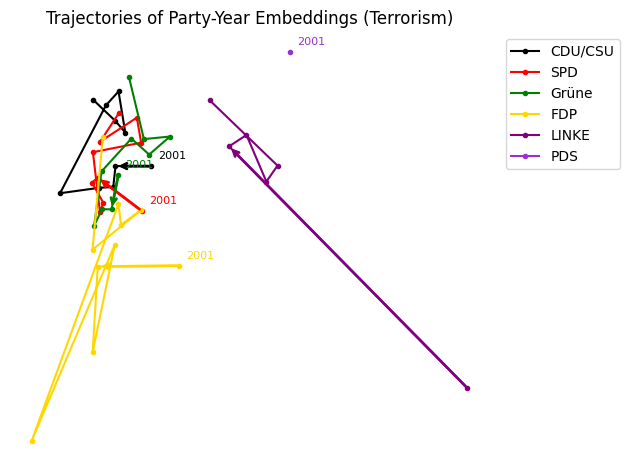

In [11]:
plot_trajectory(df_9_11, 2001, [2000, 2010], 'Terrorism')

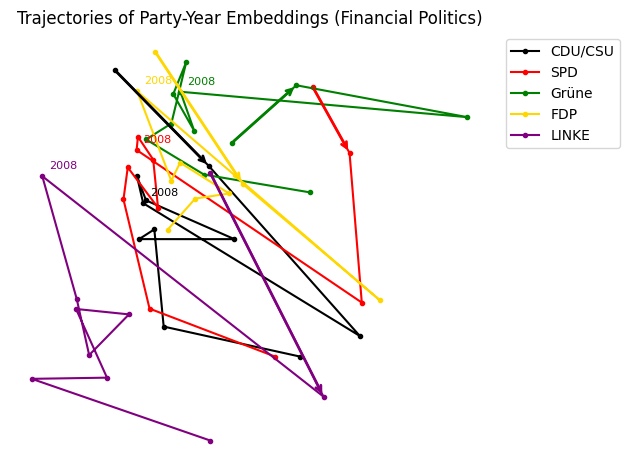

In [12]:
plot_trajectory(df_financial_crisis, 2008, [2005, 2015], 'Financial Politics')

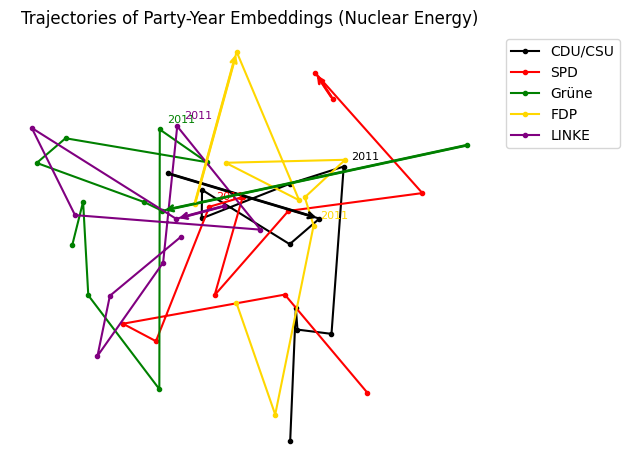

In [13]:
plot_trajectory(df_fukushima, 2011, [2005, 2015], 'Nuclear Energy')

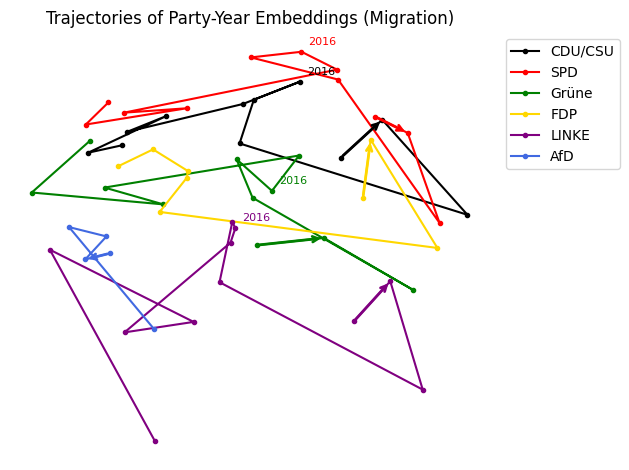

In [14]:
plot_trajectory(df_migration, 2016, [2011, 2021], 'Migration')

In [15]:
def plot_trajectory_per_party(df, year, topic):

    # aggregate the embeddings by party and year (no time restriction)
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to two dimensions
    pca_traj = PCA(n_components=2)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "dim1": pcs_traj[:, 0],
        "dim2": pcs_traj[:, 1],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    # party colors
    party_colors = {
        "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
        "FDP": "gold", "LINKE": "purple", "AfD": "royalblue",
        "PDS": "darkorchid"
    }

    # one plot per party
    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]
        if len(subset) == 0:
            continue

        plt.figure(figsize=(6, 5))
        plt.plot(subset["dim1"], subset["dim2"], color=color, marker='o', markersize=3)

        # arrows between all consecutive points, to show the full trajectory direction
        for i in range(len(subset) - 1):
            plt.annotate('', xy=(subset["dim1"].iloc[i+1], subset["dim2"].iloc[i+1]),
                                xytext=(subset["dim1"].iloc[i], subset["dim2"].iloc[i]),
                                arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.7))

        # label every year
        for i in range(len(subset)):
            plt.annotate(str(subset["year"].iloc[i]),
                        (subset["dim1"].iloc[i], subset["dim2"].iloc[i]),
                        fontsize=8, color=color,
                        textcoords="offset points", xytext=(5, 5))

        # highlight the event year, if present
        year_row = subset[subset["year"] == year]
        if not year_row.empty:
            plt.scatter(year_row["dim1"], year_row["dim2"], color=color,
                        s=80, edgecolors="black", zorder=5)

        plt.axis("off")
        plt.title(f"{party} — Trajectory of Year Embeddings ({topic})")
        plt.tight_layout()
        plt.show()

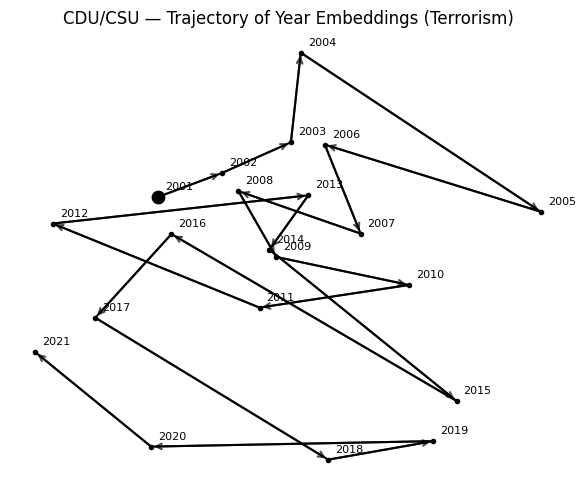

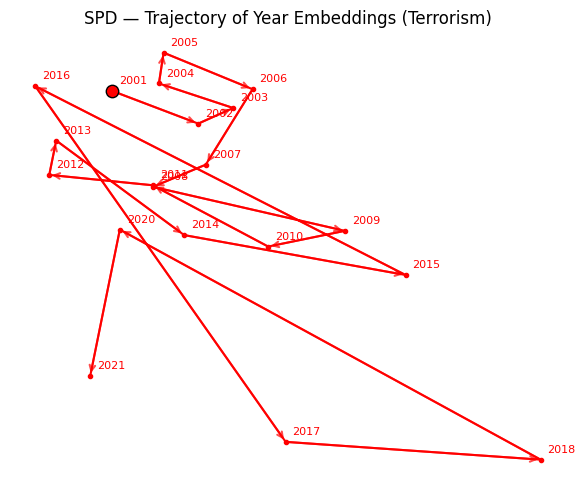

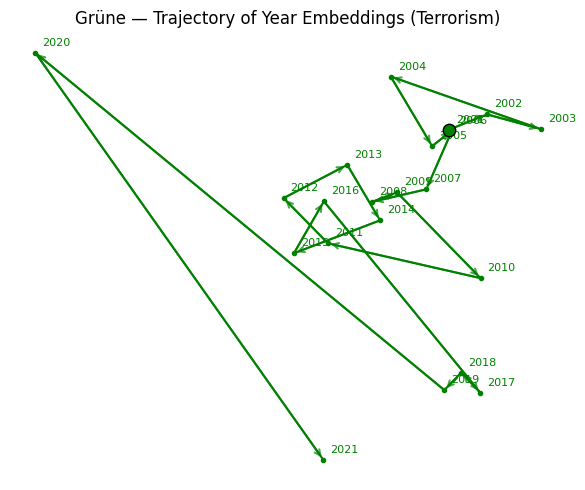

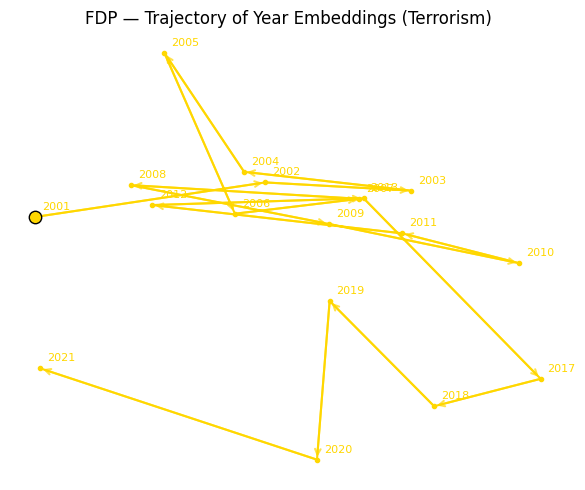

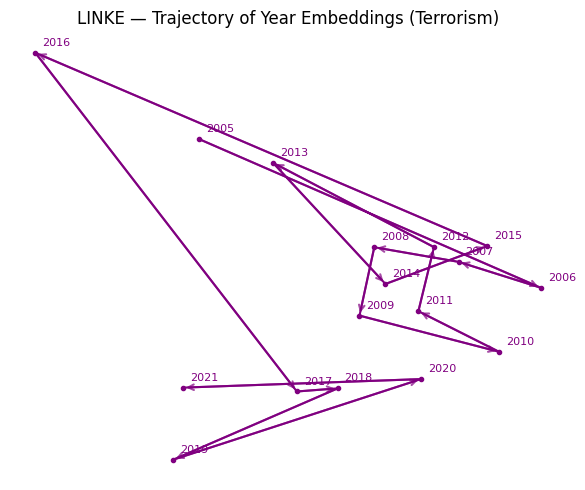

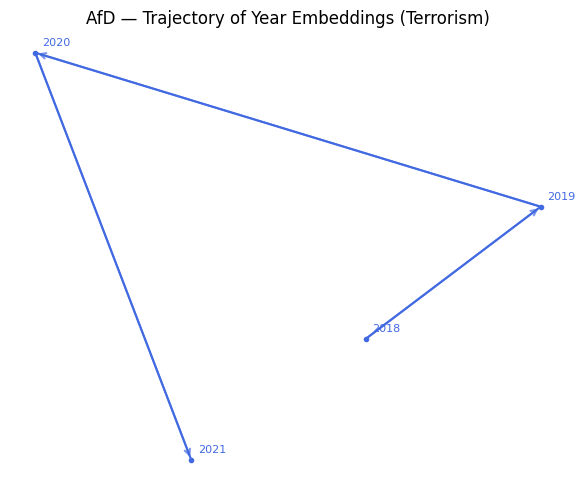

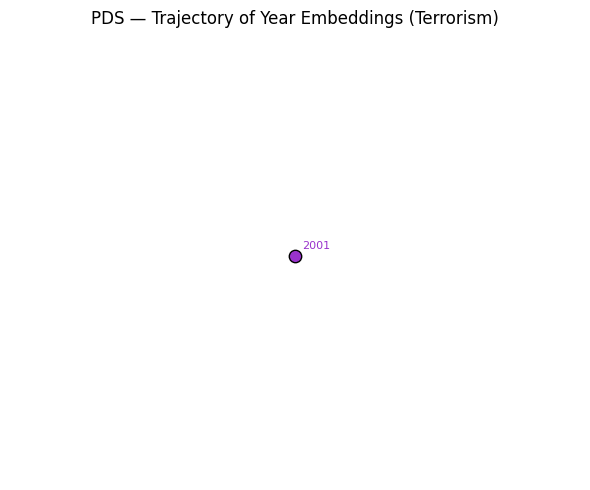

In [16]:
plot_trajectory_per_party(df_9_11, 2001, 'Terrorism')

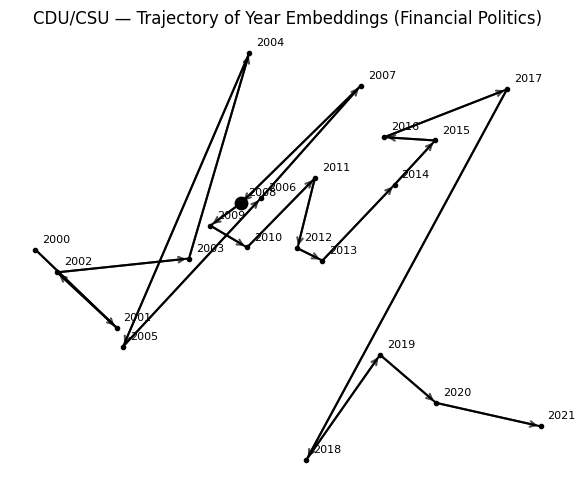

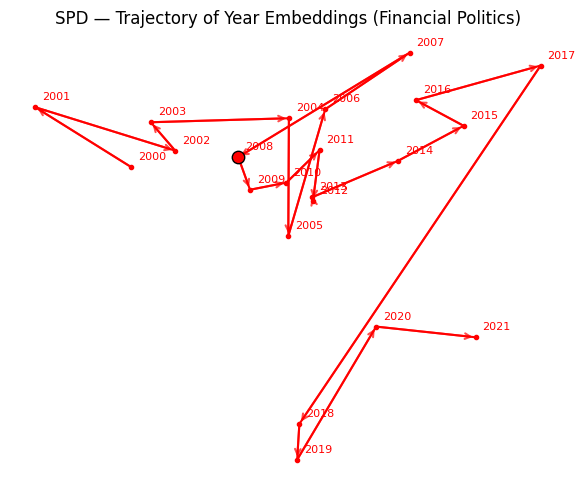

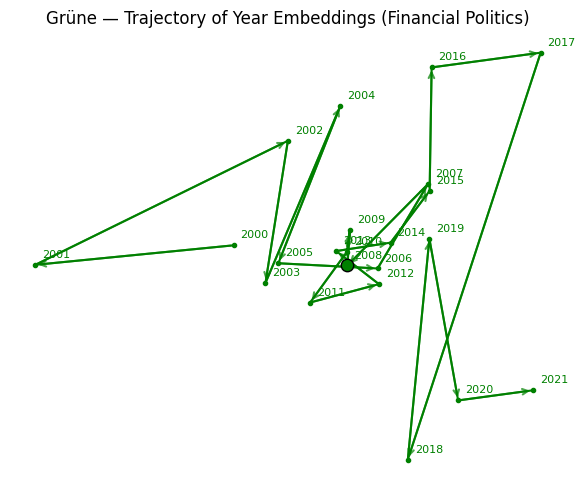

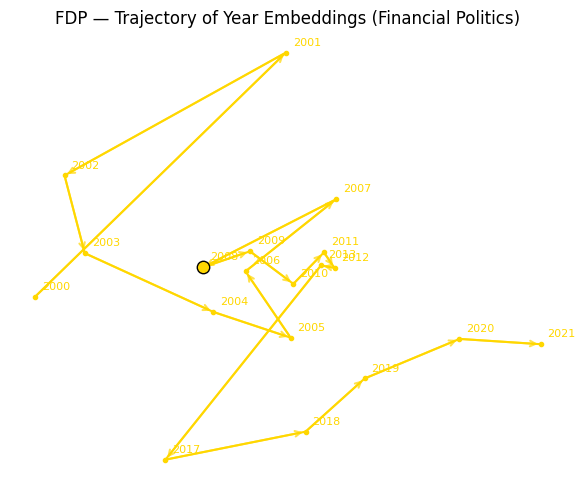

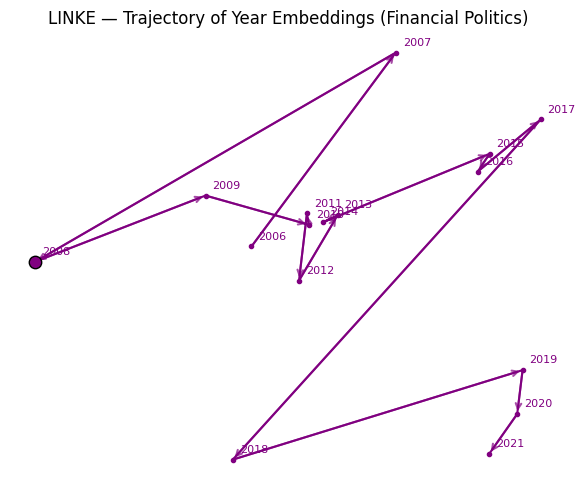

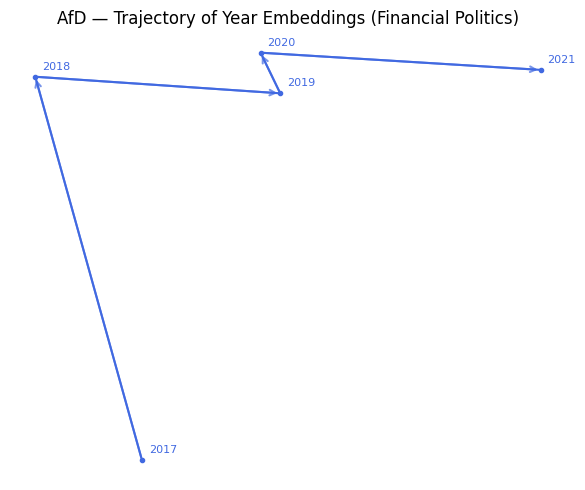

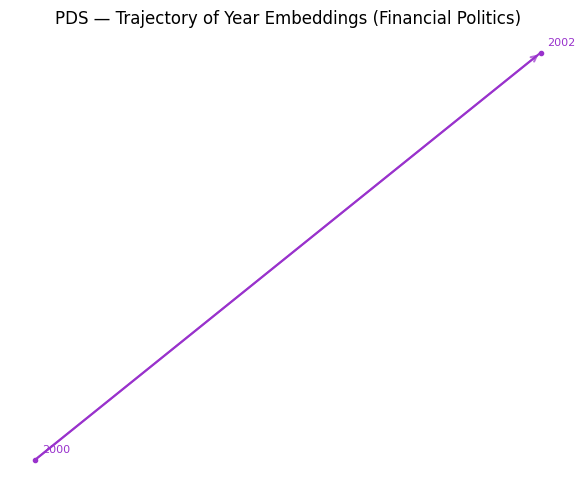

In [17]:
plot_trajectory_per_party(df_financial_crisis, 2008, 'Financial Politics')

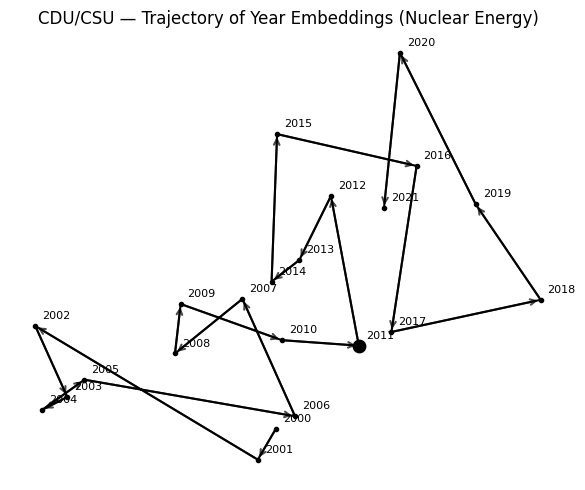

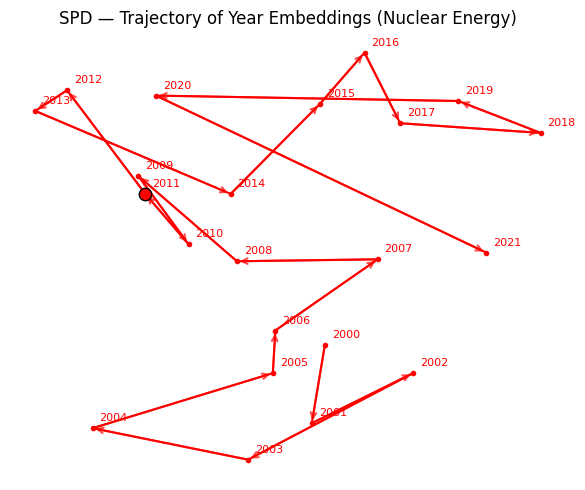

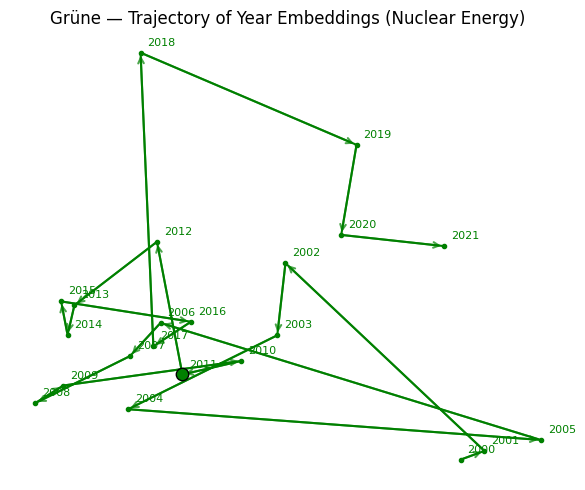

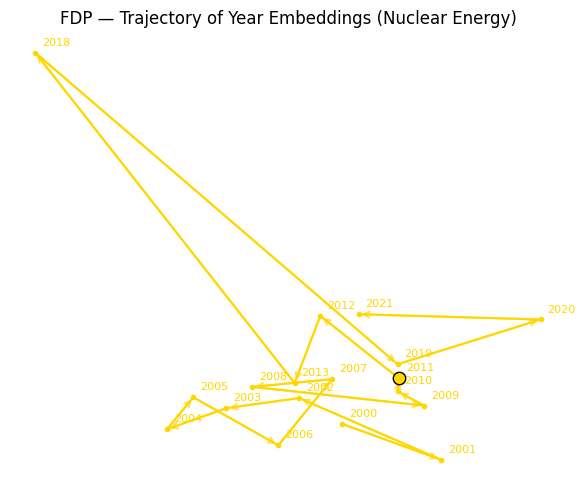

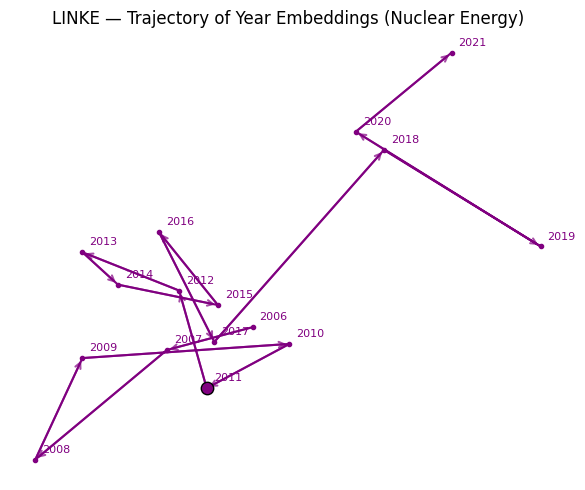

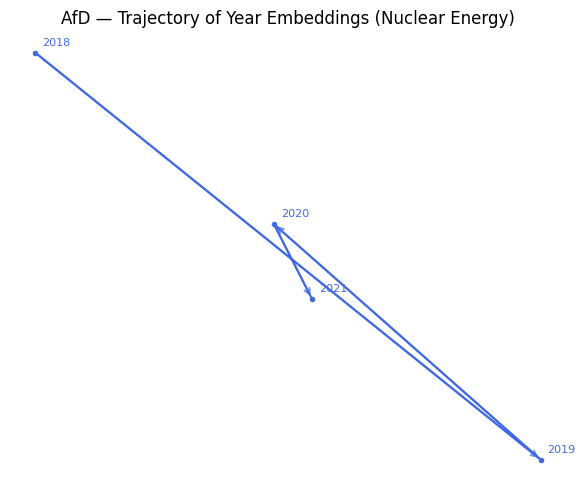

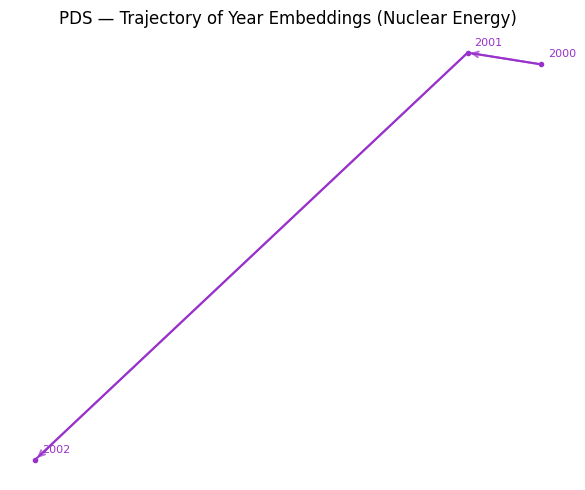

In [18]:
plot_trajectory_per_party(df_fukushima, 2011, 'Nuclear Energy')

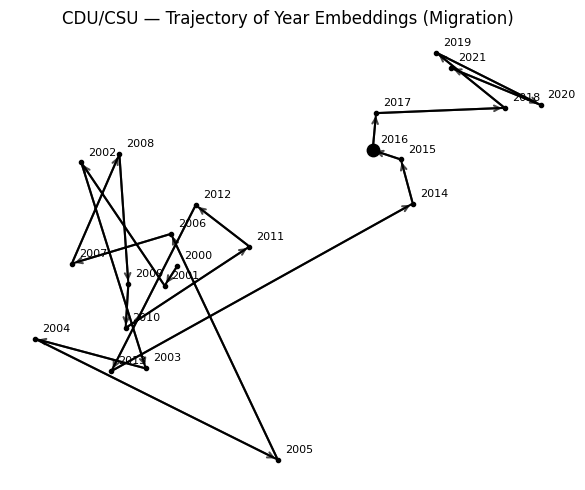

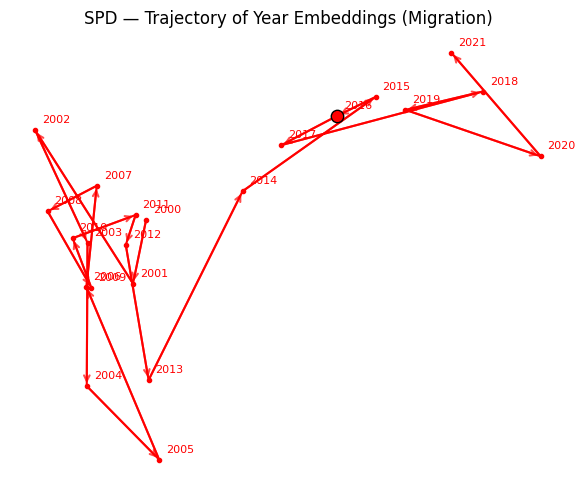

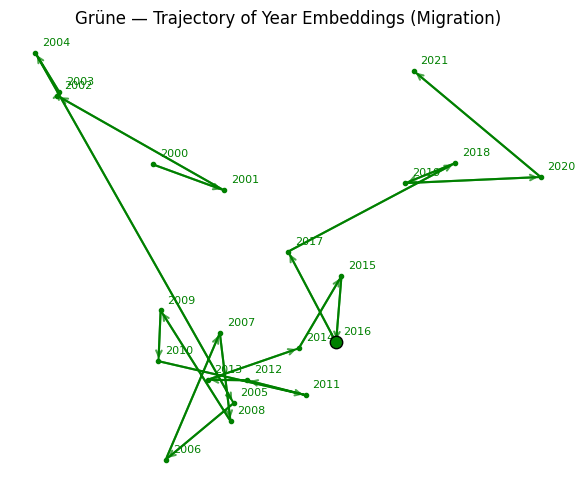

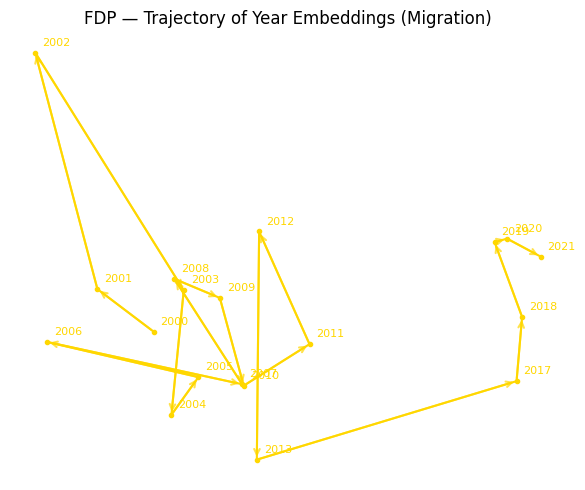

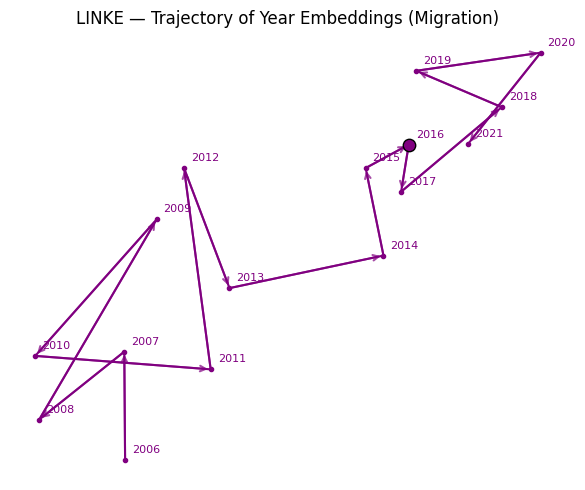

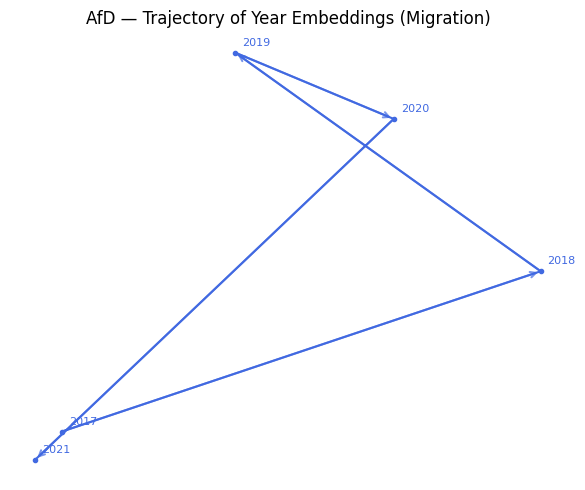

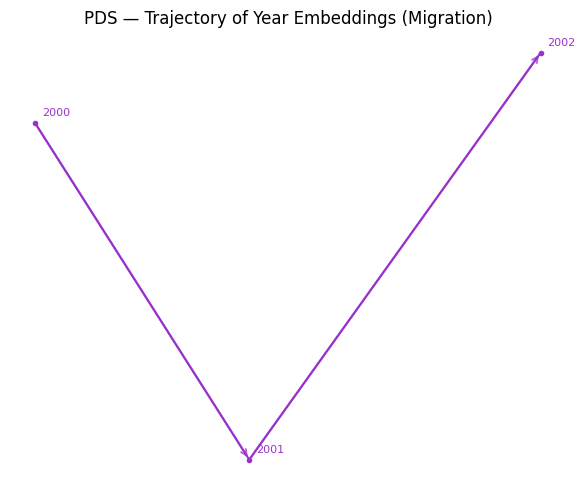

In [19]:
plot_trajectory_per_party(df_migration, 2016, 'Migration')

In [20]:
def plot_trajectory_1d(df, year, topic):

    # aggregate the embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to one dimension
    pca_traj = PCA(n_components=1)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "pc1": pcs_traj[:, 0],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    # party colors
    party_colors = {
        "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
        "FDP": "gold", "LINKE": "purple", "AfD": "royalblue",
        "PDS": "darkorchid"
    }

    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]
        if len(subset) == 0:
            continue
        plt.plot(subset["year"], subset["pc1"], color=color, label=party, marker='o', markersize=3)

    # mark the event year
    plt.axvline(year, color="grey", linestyle="--", linewidth=1)

    plt.xlabel("Year")
    plt.ylabel("PC1")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.title(f"PC1 of Party-Year Embeddings over Time ({topic})")
    plt.tight_layout()
    plt.show()

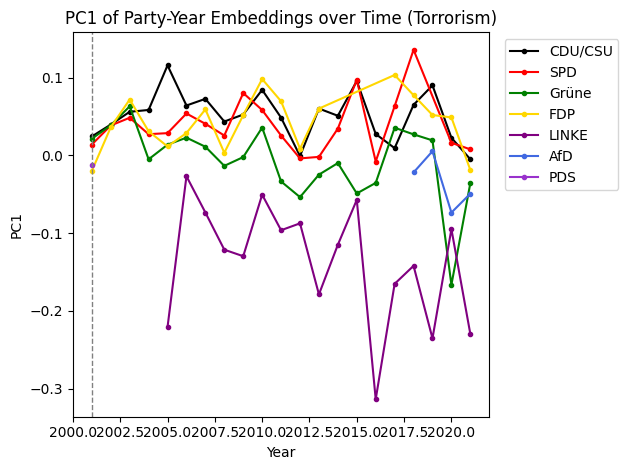

In [21]:
plot_trajectory_1d(df_9_11, 2001, 'Torrorism')

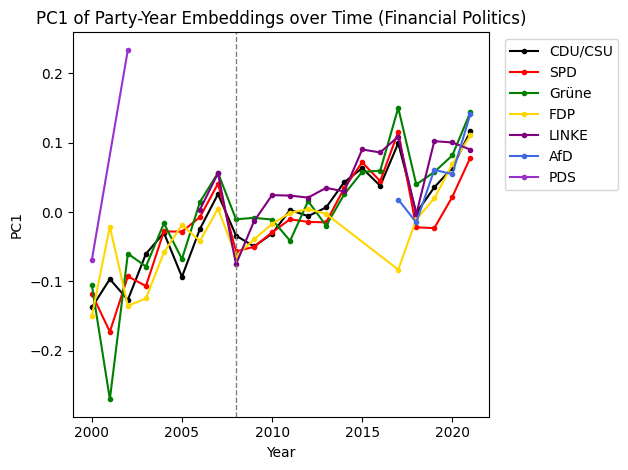

In [22]:
plot_trajectory_1d(df_financial_crisis, 2008, 'Financial Politics')

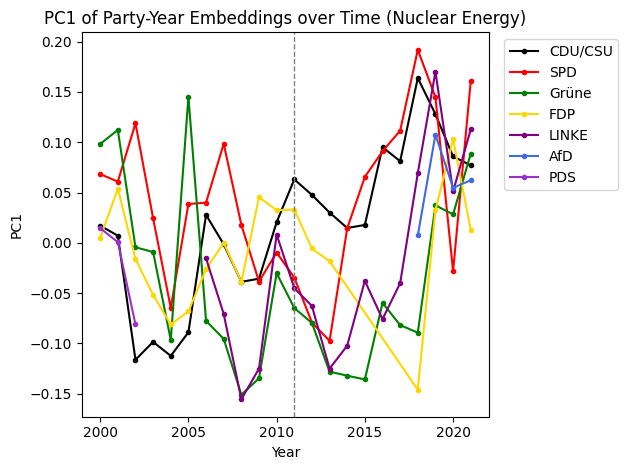

In [23]:
plot_trajectory_1d(df_fukushima, 2011, 'Nuclear Energy')

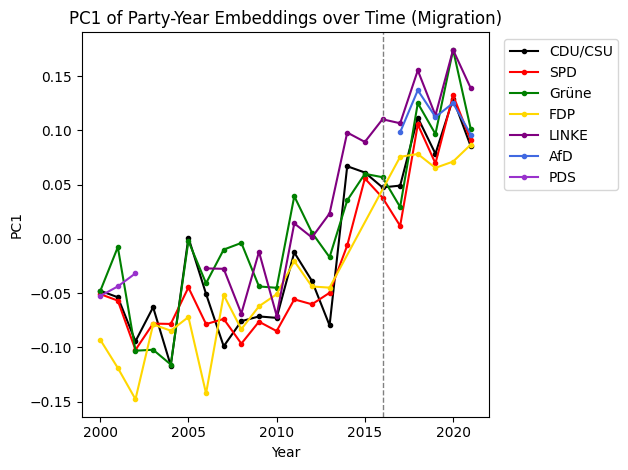

In [24]:
plot_trajectory_1d(df_migration, 2016, 'Migration')

In [50]:
def demean_by_year(df_traj, value_col="pc1"):
    """Subtracts the across-party mean per year from the given value column."""
    df_traj = df_traj.copy()
    year_means = df_traj.groupby("year")[value_col].transform("mean")
    df_traj[f"{value_col}_demeaned"] = df_traj[value_col] - year_means
    return df_traj

In [51]:
def plot_trajectory_1d_demeaned(df, year, topic):

    # aggregate the embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to one dimension
    pca_traj = PCA(n_components=1)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "pc1": pcs_traj[:, 0],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    # subtract the across-party mean per year (to remove common, year-wide shifts)
    df_party_trajectories = demean_by_year(df_party_trajectories, value_col="pc1")

    # party colors
    party_colors = {
        "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
        "FDP": "gold", "LINKE": "purple", "AfD": "royalblue",
        "PDS": "darkorchid"
    }

    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]
        if len(subset) == 0:
            continue
        plt.plot(subset["year"], subset["pc1_demeaned"], color=color, label=party, marker='o', markersize=3)

    plt.axvline(year, color="grey", linestyle="--", linewidth=1)
    plt.xlabel("Year")
    plt.ylabel("PC1 (demeaned per year)")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.title(f"PC1 of Party-Year Embeddings over Time, Demeaned ({topic})")
    plt.tight_layout()
    plt.show()

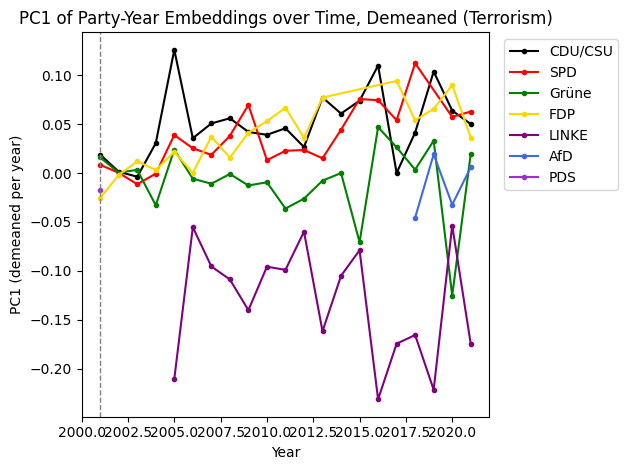

In [52]:
plot_trajectory_1d_demeaned(df_9_11, 2001, "Terrorism")

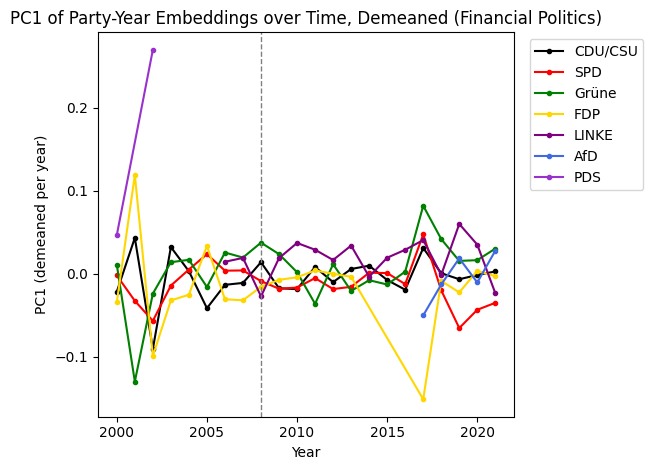

In [53]:
plot_trajectory_1d_demeaned(df_financial_crisis, 2008, "Financial Politics")

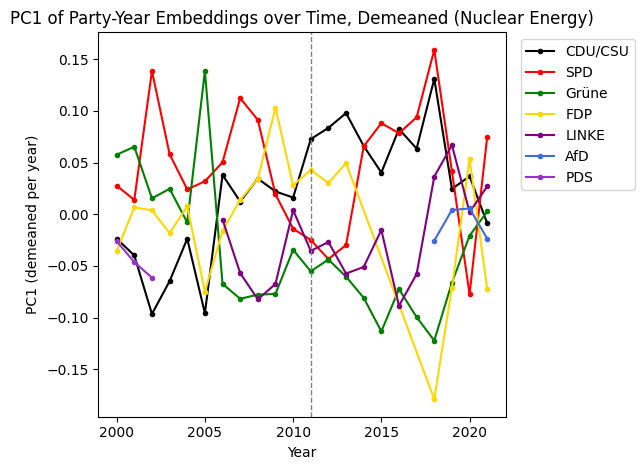

In [54]:
plot_trajectory_1d_demeaned(df_fukushima, 2011, "Nuclear Energy")

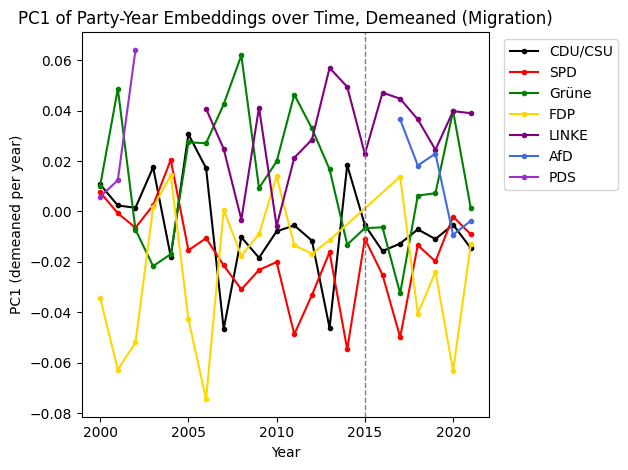

In [55]:
plot_trajectory_1d_demeaned(df_migration, 2015, "Migration")

None of these methods allowed us to visually detect any clear differences around the chosen events. We therefore try three alternative approaches: 
- instead of tracking whole parties, we focus on individual politicians who specialized in the respective topic
- for events with a clear, well-defined date (9/11, Fukushima), we examine trajectories at the monthly rather than yearly level
- instead of relying on a visual check, we compute the cosine similarity between consecutive embeddings and look for peaks in the resulting distance, indicating unusually large shifts.


In [25]:
def find_specialist_per_party(data, topic_name):
    """
    Für ein gegebenes Topic: pro Partei den Politiker/die Politikerin mit den
    meisten Reden zu diesem Topic auswählen.
    """
    topic_speeches = data[data["topic_emb_raw_name"] == topic_name]

    specialists = {}
    for party, group in topic_speeches.groupby("party"):
        top_politician = group["politicianId"].value_counts().idxmax()
        specialists[party] = top_politician

    return specialists

In [26]:
specialists_9_11 = find_specialist_per_party(df_embeddings_topics, 'isaf-mandats/isaf-mission/karzai')
specialists_finance = find_specialist_per_party(df_embeddings_topics, 'pfandbrief/vermögensanlagen/kapitalanlagegesetzbuch')
specialists_nuclear_energy = find_specialist_per_party(df_embeddings_topics, 'schwarzelühr-sutter/reaktorsicherheit/reaktoren')
specialists_migration = find_specialist_per_party(df_embeddings_topics, 'mehrstaatigkeit/dublin-ii-verordnung/optionspflicht')


In [27]:
def get_specialist_trajectories(data, specialists):
    """specialists: Dict {party: politicianId} aus find_specialist_per_party."""
    politician_ids = list(specialists.values())
    df_specialists = data[data["politicianId"].isin(politician_ids)]
    return aggregate_by_mp_year(df_specialists)

In [28]:
df_specialists_9_11 = get_specialist_trajectories(df_9_11, specialists_9_11)
df_specialists_9_11

,politicianId,year,party,n_speeches,embedding
0,11002053,2001,CDU/CSU,1,"[0.0398332, -0.12141645, 0.047952056, -0.03902..."
1,11002053,2002,CDU/CSU,1,"[0.06775649, -0.11503122, 0.08299214, 0.015198..."
2,11002053,2003,CDU/CSU,1,"[0.08779291, -0.14974762, 0.058817465, -0.0354..."
3,11002053,2007,CDU/CSU,1,"[0.08535584, -0.1389951, 0.08047374, -0.017678..."
4,11002053,2009,CDU/CSU,2,"[0.07437086, -0.1564515, 0.06643486, -0.030577..."
5,11002053,2010,CDU/CSU,5,"[0.070490554, -0.14390916, 0.07726306, -0.0304..."
6,11002053,2011,CDU/CSU,2,"[0.051907826, -0.14203927, 0.051060375, -0.019..."
7,11002053,2013,CDU/CSU,1,"[0.06034304, -0.15011972, 0.05796844, -0.02537..."
8,11002743,2002,Grüne,3,"[0.066344135, -0.15307622, 0.056960255, -0.014..."
9,11002743,2003,Grüne,1,"[0.039720103, -0.1462663, 0.064458266, -0.0426..."


In [29]:
df_specialists_finance = get_specialist_trajectories(df_financial_crisis, specialists_finance)
df_specialists_finance

,politicianId,year,party,n_speeches,embedding
0,11000921,2000,PDS,1,"[0.105008624, -0.104357645, -0.029954134, -0.0..."
1,11000921,2006,LINKE,1,"[0.09428888, -0.077313505, 0.037610184, -0.011..."
2,11000921,2007,LINKE,2,"[0.04149736, -0.08038124, -0.00066547, -0.0069..."
3,11000921,2008,LINKE,2,"[0.104723096, -0.10059087, -0.0128194755, -0.0..."
4,11000921,2009,LINKE,2,"[0.114496514, -0.05786836, -0.0031456351, -0.0..."
...,...,...,...,...,...
56,11004157,2013,SPD,8,"[0.1009015, -0.073353544, -0.0020755623, -0.02..."
57,11004157,2014,SPD,3,"[0.06243811, -0.038161267, 0.007926325, -0.024..."
58,11004157,2015,SPD,2,"[0.07041411, -0.051819257, 0.008494938, -0.025..."
59,11004760,2018,AfD,2,"[0.08479479, -0.06541125, 0.013346652, -0.0182..."


In [30]:
df_specialists_fukushima = get_specialist_trajectories(df_fukushima, specialists_nuclear_energy)
df_specialists_fukushima

,politicianId,year,party,n_speeches,embedding
0,11002677,2001,PDS,2,"[0.10075142, -0.12963633, 0.08254263, -0.01866..."
1,11002812,2001,CDU/CSU,2,"[0.12159636, -0.13694246, 0.044787675, -0.0095..."
2,11002812,2010,CDU/CSU,1,"[0.103873305, -0.14050974, 0.020553444, -0.014..."
3,11003450,2001,SPD,1,"[0.115439005, -0.12431671, 0.046310224, -0.033..."
4,11003450,2004,SPD,1,"[0.105739, -0.12452609, 0.010788814, -0.009417..."
5,11003450,2006,SPD,1,"[0.08627636, -0.09736979, 0.02540849, -0.03172..."
6,11003450,2009,SPD,1,"[0.07380264, -0.10769714, 0.028285587, 0.00319..."
7,11003450,2010,SPD,14,"[0.09212219, -0.12145165, 0.032978535, -0.0260..."
8,11003450,2011,SPD,9,"[0.10764852, -0.12959892, 0.05918973, -0.00723..."
9,11003450,2012,SPD,2,"[0.10392913, -0.14219125, 0.07724297, -0.02840..."


In [31]:
df_specialists_migration = get_specialist_trajectories(df_migration, specialists_migration)
df_specialists_migration

,politicianId,year,party,n_speeches,embedding
0,11001023,2000,PDS,6,"[0.019995324, -0.14479679, 0.08593189, 0.01697..."
1,11001023,2001,PDS,3,"[0.014566686, -0.14010738, 0.07953859, 0.01412..."
2,11001023,2006,LINKE,4,"[0.0032662828, -0.13357493, 0.09007467, -0.007..."
3,11001023,2007,LINKE,6,"[0.02310902, -0.14631854, 0.10128971, 0.003478..."
4,11001023,2008,LINKE,2,"[0.045828428, -0.14256574, 0.08438596, 0.02303..."
...,...,...,...,...,...
68,11004698,2017,AfD,2,"[0.023584506, -0.1587993, 0.08485661, -0.00972..."
69,11004698,2018,AfD,10,"[0.025473038, -0.14123592, 0.09586431, 0.00756..."
70,11004698,2019,AfD,10,"[0.020783197, -0.15409687, 0.080580935, 0.0088..."
71,11004698,2020,AfD,7,"[0.042015195, -0.13553895, 0.10485357, -0.0152..."


In [32]:
def plot_trajectory_1d_specialists(df, year, topic, specialists):
    df_agg = aggregate_by_mp_year(df)

    stack = np.stack(df_agg['embedding'])
    pca_traj = PCA(n_components=1)
    pcs_traj = pca_traj.fit_transform(stack)

    df_traj = pd.DataFrame({
        "pc1": pcs_traj[:, 0],
        "politicianId": df_agg.politicianId,
        "party": df_agg.party,
        "year": df_agg.year
    })
    df_traj = df_traj.sort_values(["politicianId", "year"])

    party_colors = {
        "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
        "FDP": "gold", "LINKE": "purple", "AfD": "royalblue",
        "PDS": "darkorchid"
    }

    for party, politician_id in specialists.items():
        subset = df_traj[df_traj["politicianId"] == politician_id]
        if len(subset) == 0:
            continue
        plt.plot(subset["year"], subset["pc1"], color=party_colors[party],
                  label=f"{party} ({politician_id})", marker='o', markersize=3)

    plt.axvline(year, color="grey", linestyle="--", linewidth=1)
    plt.xlabel("Year")
    plt.ylabel("PC1")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.title(f"PC1 of Specialist MP Embeddings over Time ({topic})")
    plt.tight_layout()
    plt.show()

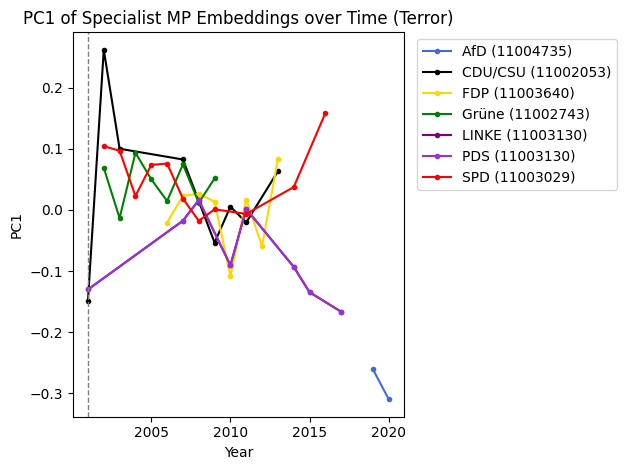

In [33]:
plot_trajectory_1d_specialists(df_specialists_9_11, 2001, 'Terror', specialists_9_11)

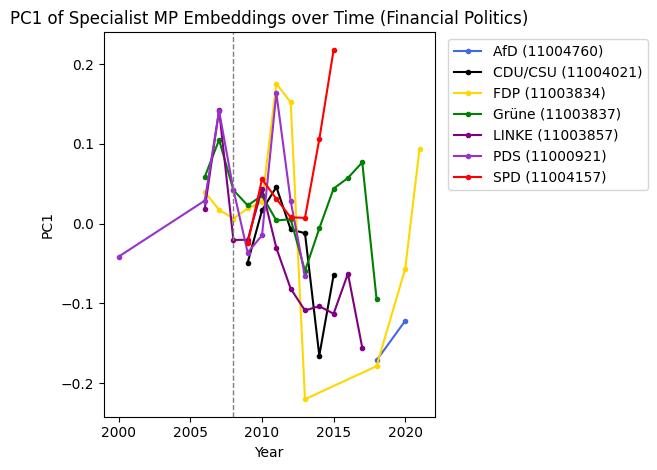

In [34]:
plot_trajectory_1d_specialists(df_specialists_finance, 2008, 'Financial Politics', specialists_finance)

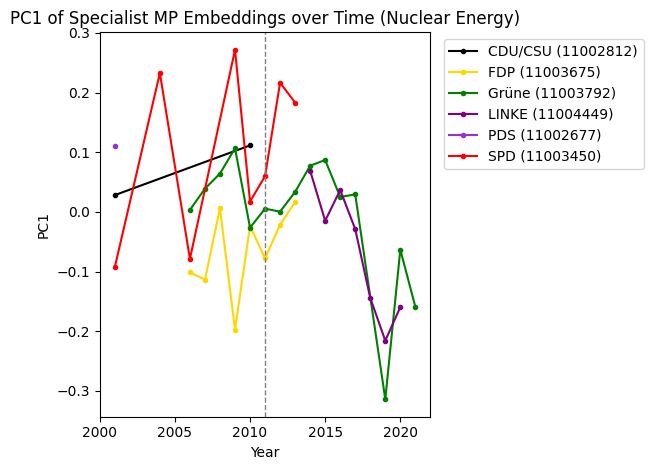

In [35]:
plot_trajectory_1d_specialists(df_specialists_fukushima, 2011, 'Nuclear Energy', specialists_nuclear_energy)

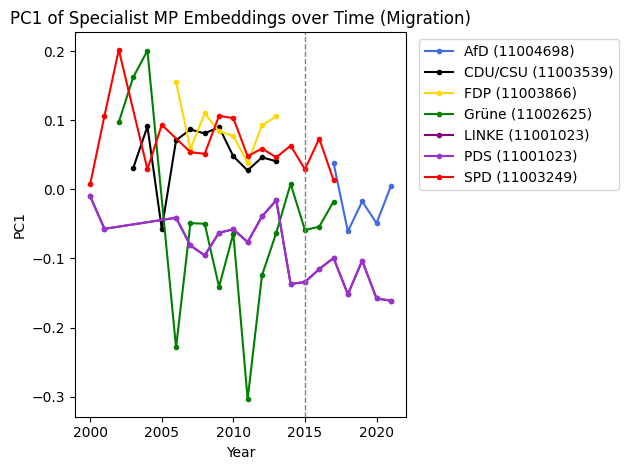

In [36]:
plot_trajectory_1d_specialists(df_specialists_migration, 2015, 'Migration', specialists_migration)

## Cosine Similarity

In [44]:
def compute_distance_series(df, topic):
    """
    Aggregates the (already topic-filtered) speeches by party and year,
    then computes the cosine distance between each party's embedding
    in consecutive years.
    """
    df_agg = aggregate_by_party_year(df)
    df_agg = df_agg.sort_values(["party", "year"])

    party_colors = {
        "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
        "FDP": "gold", "LINKE": "purple", "AfD": "royalblue",
        "PDS": "darkorchid"
    }

    records = []
    for party, color in party_colors.items():
        subset = df_agg[df_agg["party"] == party].sort_values("year")
        if len(subset) < 2:
            continue

        embeddings = np.stack(subset["embedding"])
        years = subset["year"].values

        for i in range(1, len(embeddings)):
            sim = cosine_similarity(embeddings[i-1].reshape(1, -1), embeddings[i].reshape(1, -1))[0, 0]
            distance = 1 - sim
            records.append({
                "party": party,
                "year": years[i],
                "distance": distance
            })

    return pd.DataFrame(records)


def plot_distance_series(df, topic, event_year):
    df_dist = compute_distance_series(df, topic)

    party_colors = {
        "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
        "FDP": "gold", "LINKE": "purple", "AfD": "royalblue",
        "PDS": "darkorchid"
    }

    for party, color in party_colors.items():
        subset = df_dist[df_dist["party"] == party]
        if len(subset) == 0:
            continue
        plt.plot(subset["year"], subset["distance"], color=color, label=party, marker='o', markersize=3)

    plt.axvline(event_year, color="grey", linestyle="--", linewidth=1)
    plt.xlabel("Year")
    plt.ylabel("Cosine Distance to Previous Year")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.title(f"Year-over-Year Embedding Distance ({topic})")
    plt.xticks(sorted(df_dist["year"].unique()), rotation=45)
    plt.tight_layout()
    plt.show()

    return df_dist

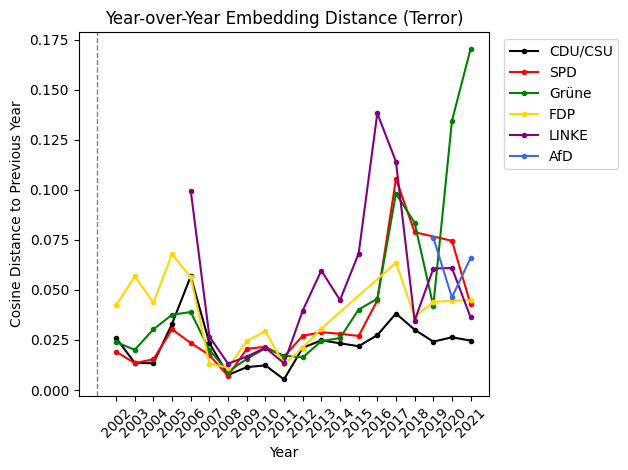

,party,year,distance
0,CDU/CSU,2002,0.026006
1,CDU/CSU,2003,0.013547
2,CDU/CSU,2004,0.013373
3,CDU/CSU,2005,0.033081
4,CDU/CSU,2006,0.056840
...,...,...,...
90,LINKE,2020,0.061024
91,LINKE,2021,0.036264
92,AfD,2019,0.076202
93,AfD,2020,0.046296


In [45]:
df_dist_9_11 = plot_distance_series(df_9_11, "Terror", 2001)
df_dist_9_11

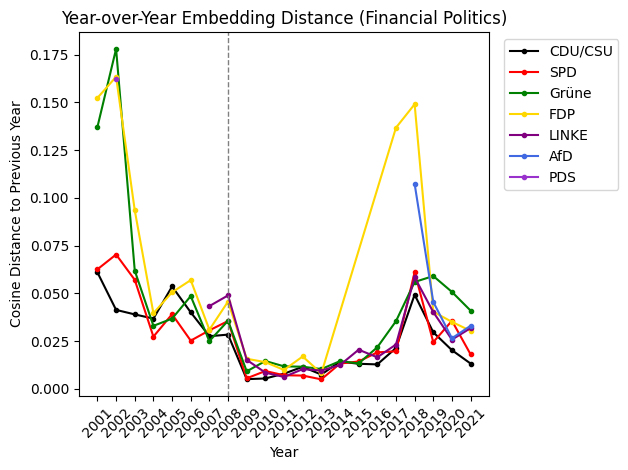

,party,year,distance
0,CDU/CSU,2001,0.060981
1,CDU/CSU,2002,0.041341
2,CDU/CSU,2003,0.038979
3,CDU/CSU,2004,0.036788
4,CDU/CSU,2005,0.053598
...,...,...,...
96,AfD,2018,0.107360
97,AfD,2019,0.045500
98,AfD,2020,0.026481
99,AfD,2021,0.033036


In [46]:
df_dist_finance = plot_distance_series(df_financial_crisis, "Financial Politics", 2008)
df_dist_finance

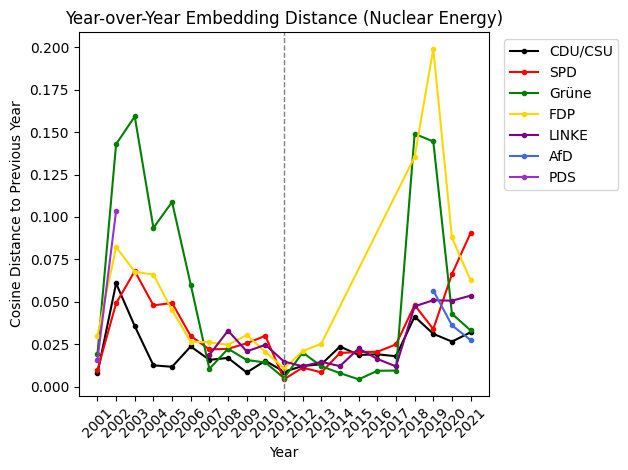

,party,year,distance
0,CDU/CSU,2001,0.007793
1,CDU/CSU,2002,0.060870
2,CDU/CSU,2003,0.035662
3,CDU/CSU,2004,0.012572
4,CDU/CSU,2005,0.011685
...,...,...,...
95,AfD,2019,0.056605
96,AfD,2020,0.036153
97,AfD,2021,0.027436
98,PDS,2001,0.015827


In [47]:
df_dist_fukushima = plot_distance_series(df_fukushima, "Nuclear Energy", 2011)
df_dist_fukushima

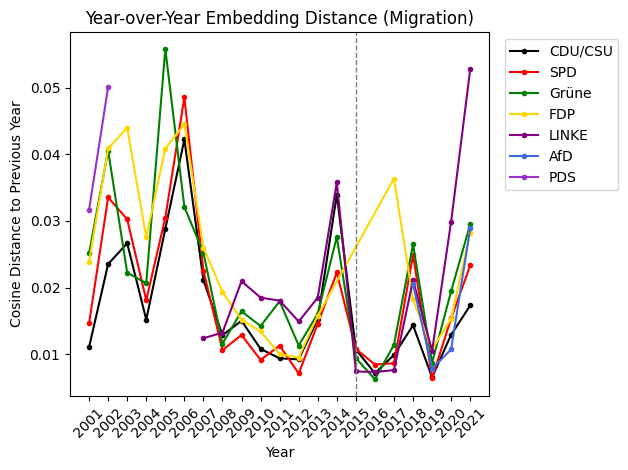

,party,year,distance
0,CDU/CSU,2001,0.011078
1,CDU/CSU,2002,0.023537
2,CDU/CSU,2003,0.026655
3,CDU/CSU,2004,0.015196
4,CDU/CSU,2005,0.028815
...,...,...,...
97,AfD,2019,0.007801
98,AfD,2020,0.010756
99,AfD,2021,0.028880
100,PDS,2001,0.031703


In [48]:
df_dist_migration = plot_distance_series(df_migration, "Migration", 2015)
df_dist_migration

## 2. Track MPs